In [28]:
import numpy as np 
import cv2 
import matplotlib.pyplot as plt 

path="WhatsApp Image 2026-03-24 at 6.13.59 PM.jpeg"
maskpath = "WhatsApp Image 2026-03-24 at 6.14.17 PM.jpeg"
image = cv2.imread(path,0) 
maskimg = cv2.imread(maskpath,0)
# clahe = cv2.createCLAHE(2.0 , (8,8)) 

# claheimg = clahe.apply(image) 

# fig,axes = plt.subplots(1,2) 
# axes[0].imshow(claheimg,cmap="gray") 
# axes[1].imshow(image,cmap="gray")

# plt.show()

hist = cv2.calcHist([image],[0],maskimg,[256],[0,256]) 
hist= hist.ravel() 
hist = hist/hist.sum()

In [29]:
def entropy(region): 
    region = region[region > 0]
    if len(region) == 0:
        return 0
    region = region / np.sum(region)  #normalization for each region ? 
    return -np.sum(region * np.log(region))


def shannonforT(T):
    t1, t2 = sorted(T)

    r1 = hist[:t1]
    r2 = hist[t1:t2]
    r3 = hist[t2:]

    H = entropy(r1) + entropy(r2) + entropy(r3)
    return H

In [30]:
def initialize(N, dim, lb, ub):
    X = np.random.uniform(lb, ub, (N, dim))   # thresholds
    den = np.random.rand(N, dim)
    vol = np.random.rand(N, dim)
    acc = lb + np.random.rand(N, dim) * (ub - lb)
    return X, den, vol, acc

def update_den_vol(den, vol, den_best, vol_best):
    rand = np.random.rand(*den.shape)
    
    den = den + rand * (den_best - den)
    vol = vol + rand * (vol_best - vol)
    
    return den, vol

In [31]:
def compute_TF(t, tmax):
    return np.exp((t - tmax) / tmax)

def compute_d(t, tmax):
    return np.exp((tmax - t) / tmax) - (t / tmax)

In [32]:
def update_acc(acc, den, vol, den_best, vol_best, acc_best, TF):
    
    new_acc = np.zeros_like(acc)
    
    for i in range(len(acc)):
        if TF <= 0.5:
            # exploration
            mr = np.random.randint(len(acc))
            new_acc[i] = (den[mr] + vol[mr] * acc[mr]) / (den[i] * vol[i] + 1e-9)
        else:
            # exploitation
            new_acc[i] = (den_best + vol_best * acc_best) / (den[i] * vol[i] + 1e-9)
    
    return new_acc

def normalize_acc(acc):
    acc_min = acc.min()
    acc_max = acc.max()
    
    return 0.9 * (acc - acc_min) / (acc_max - acc_min + 1e-9) + 0.1 

In [33]:


def update_position(X, acc_norm, best, TF, d, lb, ub):
    
    C1 = 2
    C2 = 6
    
    new_X = np.copy(X)
    
    for i in range(len(X)):
        rand = np.random.rand()
        
        if TF <= 0.5:
            # exploration
            rand_idx = np.random.randint(len(X))
            new_X[i] = X[i] + C1 * rand * acc_norm[i] * d * (X[rand_idx] - X[i])
        
        else:
            # exploitation
            F = 1 if np.random.rand() < 0.5 else -1
            new_X[i] = best + F * C2 * rand * acc_norm[i] * d * (best - X[i])
        
        new_X[i] = np.clip(new_X[i], lb, ub)
    
    return new_X

In [34]:
def AOA(hist, fitness_func, N=20, dim=2, iters=50):

    lb, ub = 1, 254
    
    X, den, vol, acc = initialize(N, dim, lb, ub)
    
    best = None
    best_score = -np.inf
    
    for t in range(iters):
        
        scores = np.array([fitness_func(x.astype(int)) for x in X])
        
        idx = np.argmax(scores)
        
        if scores[idx] > best_score:
            best_score = scores[idx]
            best = X[idx].copy()
            den_best = den[idx].copy()
            vol_best = vol[idx].copy()
            acc_best = acc[idx].copy()
        
        TF = compute_TF(t, iters)
        d = compute_d(t, iters)
        
        den, vol = update_den_vol(den, vol, den_best, vol_best)
        
        acc = update_acc(acc, den, vol, den_best, vol_best, acc_best, TF)
        
        acc_norm = normalize_acc(acc)
        
        X = update_position(X, acc_norm, best, TF, d, lb, ub)
    
    return sorted(best.astype(int))


In [35]:
res = AOA(hist, shannonforT ) 

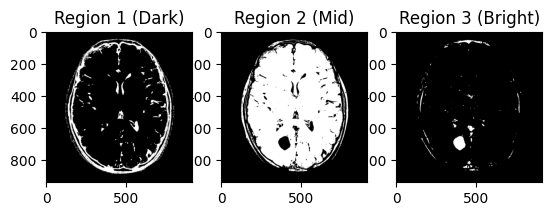

In [37]:
refimg = cv2.imread(path,0)
r1 = refimg.copy()
r2 = refimg.copy()
r3 = refimg.copy()
r1[r1 >= res[0]] = 0
r2[r2<res[0]] = 0 
r2[r2>res[1]] = 0
r3[r3<=res[1]] = 0 
            
fig ,axes = plt.subplots(1,3)
# axes[0].imshow(r1,cmap="gray")
# axes
# axes[1].imshow(r2,cmap="gray")
# axes[2].imshow(r3,cmap="gray")
axes[0].imshow(r1 > 0, cmap='gray')
axes[0].set_title("Region 1 (Dark)")

axes[1].imshow(r2 > 0, cmap='gray')
axes[1].set_title("Region 2 (Mid)")

axes[2].imshow(r3 > 0, cmap='gray')
axes[2].set_title("Region 3 (Bright)")

plt.show()


